<a href="https://colab.research.google.com/github/nonyeezeh/MAS-Research-Code/blob/main/Wealth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

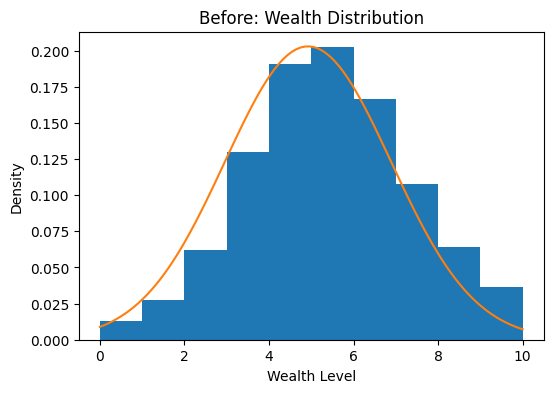

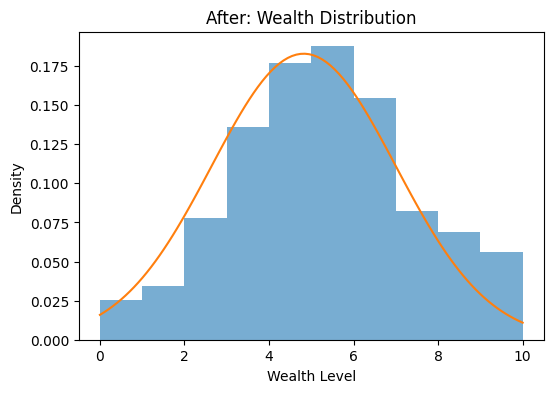


--- TRANSITION MATRIX (%) ---

from \ to   low     mid     high
low         98.0%    2.0%    0.0%
mid          0.9%   98.2%    0.9%
high         0.0%    3.1%   96.9%

Gini Before: 0.2
Gini After: 0.3


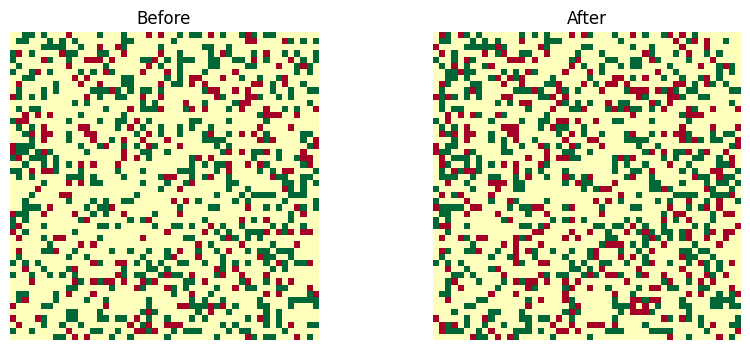

In [33]:
# -----------------------
# PARAMETERS
# -----------------------
size = 50
wealth_growth_rate = 0.2 # test 0.2 and 0.8 with 10 steps

# -----------------------
# INITIAL WEALTH
# -----------------------
wealth = np.random.normal(5, 2, (size, size))
wealth = np.clip(wealth, 0, 10)
wealth = np.rint(wealth).astype(int)

# -----------------------
# THRESHOLDS
# -----------------------
def compute_thresholds(w):
    mean = np.mean(w)
    std = np.std(w)
    return mean - std, mean + std

lower_threshold, upper_threshold = compute_thresholds(wealth)

# -----------------------
# HISTOGRAM (BEFORE)
# -----------------------
plt.figure(figsize=(6,4))

values = wealth.flatten()
plt.hist(values, bins=10, density=True, alpha=1)

x = np.linspace(min(values), max(values), 100)
y = (1/(np.std(values)*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-np.mean(values))/np.std(values))**2)

plt.plot(x, y)

plt.title("Before: Wealth Distribution")
plt.xlabel("Wealth Level")
plt.ylabel("Density")
plt.show()

# -----------------------
# CLASS FUNCTION
# -----------------------
def get_classes():
    classes = np.zeros((size,size))

    classes[wealth < lower_threshold] = 0
    classes[(wealth >= lower_threshold) & (wealth < upper_threshold)] = 1
    classes[wealth >= upper_threshold] = 2

    return classes

# -----------------------
# STEP FUNCTION
# -----------------------
def step():
    global wealth

    classes = get_classes()

    mean = np.mean(wealth)
    std = np.std(wealth) + 1e-8

    for i in range(size):
        for j in range(size):

            agent_class = classes[i,j]

            # -----------------------
            # UPWARD MOBILITY (MODIFIED)
            # -----------------------
            if agent_class == 0:
                base_up = 0.1
            elif agent_class == 1:
                base_up = 0.2
            else:
                base_up = 0.4

            p_up = base_up * wealth_growth_rate

            # -----------------------
            # DOWNWARD MOBILITY (SAME)
            # -----------------------
            z = (wealth[i,j] - mean) / std
            alpha = 0.02
            base_down = 0.05
            p_down = base_down + alpha * max(0, z)

            # -----------------------
            # APPLY CHANGE
            # -----------------------
            r = np.random.random()

            if r < p_up:
                wealth[i,j] += 1
            elif r < p_up + p_down:
                wealth[i,j] -= 1

    wealth = np.clip(wealth, 0, 10).astype(int)

# -----------------------
# BEFORE STATE
# -----------------------
classes_before = get_classes()

# -----------------------
# TRANSITION MATRIX
# -----------------------
transition_matrix = np.zeros((3,3))

# -----------------------
# RUN SIMULATION
# -----------------------
steps = 10

for _ in range(steps):

    old_classes = get_classes().copy()

    step()

    new_classes = get_classes()

    for i in range(size):
        for j in range(size):
            transition_matrix[
                int(old_classes[i, j]),
                int(new_classes[i, j])
            ] += 1

# -----------------------
# AFTER STATE
# -----------------------
classes_after = get_classes()

# -----------------------
# HISTOGRAM (AFTER)
# -----------------------
plt.figure(figsize=(6,4))

values_after = wealth.flatten()
plt.hist(values_after, bins=10, density=True, alpha=0.6)

x = np.linspace(min(values_after), max(values_after), 100)
y = (1/(np.std(values_after)*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-np.mean(values_after))/np.std(values_after))**2)

plt.plot(x, y)

plt.title("After: Wealth Distribution")
plt.xlabel("Wealth Level")
plt.ylabel("Density")
plt.show()

# -----------------------
# TRANSITION PERCENTAGES
# -----------------------
transition_percent = transition_matrix / (transition_matrix.sum(axis=1, keepdims=True) + 1e-8)

labels = ["low", "mid", "high"]

print("\n--- TRANSITION MATRIX (%) ---\n")
print("from \\ to   low     mid     high")

for i in range(3):
    row = transition_percent[i]
    print(
        f"{labels[i]:<5}      "
        f"{row[0]*100:5.1f}%  "
        f"{row[1]*100:5.1f}%  "
        f"{row[2]*100:5.1f}%"
    )

# -----------------------
# GINI COEFFICIENT
# -----------------------
def gini(array):
    array = array.flatten()
    array = np.sort(array)
    n = len(array)

    cumulative = np.cumsum(array)
    gini_value = (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n
    return gini_value

print("\nGini Before:", round(gini(values), 1))
print("Gini After:", round(gini(values_after), 1))

# -----------------------
# GRID COMPARISON
# -----------------------
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].imshow(classes_before, cmap="RdYlGn", vmin=0, vmax=2)
ax[0].set_title("Before")
ax[0].axis("off")

ax[1].imshow(classes_after, cmap="RdYlGn", vmin=0, vmax=2)
ax[1].set_title("After")
ax[1].axis("off")

plt.show()